# 03 — Inventory-Policy Segmentation

Not every SKU should be managed the same way. This notebook segments series by how
*forecastable*, *variable*, and *valuable* they are, and maps each segment to an
operating decision: a **service-level target** and a **policy class**. Those targets
feed the inventory simulator (notebook 04/05), so segmentation is what connects the
forecast quality of each SKU to how aggressively the system tries to keep it in
stock.

The segmentation axes are:
* **Forecastability** — per-series RMSSE from notebook 01 (lower = more predictable).
* **Demand variability** — coefficient of variation and intermittency (zero-day fraction).
* **Volume / value** — mean daily units and total revenue share.

A high-value, predictable item earns a high service target and full automation; an
intermittent, erratic long-tail item gets a conservative, simple policy because
chasing its service level just piles up dead stock.

**Inputs:** `data/series_meta.parquet`, `data/series_scores.parquet`
**Output:** `data/segments.parquet`

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

ROOT = Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sns.set_style("whitegrid"); plt.rcParams.update({"figure.dpi":110})
meta = pd.read_parquet(ROOT/"data"/"series_meta.parquet")
scores = pd.read_parquet(ROOT/"data"/"series_scores.parquet")
df = meta.merge(scores, on="series_id", how="left")
print("series:", len(df))
df[["series_id","mean_units","cv","zero_frac","rmsse"]].head(3)

series: 10000


,series_id,mean_units,cv,zero_frac,rmsse
0,FOODS_1_001--CA_2,0.949919,1.612109,0.535541,0.515545
1,FOODS_1_001--CA_3,1.005654,2.335697,0.626817,0.502080
2,FOODS_1_003--CA_1,0.758481,1.441527,0.552504,0.655377


Build the segmentation feature matrix and standardise it.

In [2]:
df["forecastability"] = 1.0/(1.0+df["rmsse"].fillna(df["rmsse"].median()))
df["cv"] = df["cv"].fillna(df["cv"].median()).clip(upper=df["cv"].quantile(0.99))
df["log_rev"] = np.log1p(df["total_rev"])
feat = ["forecastability","cv","zero_frac","log_rev","mean_units"]
X = StandardScaler().fit_transform(df[feat].values)
print("feature matrix:", X.shape)

feature matrix: (10000, 5)


Cluster into four inventory-management segments with K-means.

In [3]:
K = 4
km = KMeans(n_clusters=K, n_init=10, random_state=42)
df["cluster"] = km.fit_predict(X)
prof = df.groupby("cluster")[feat].mean().round(3)
prof["n"] = df.groupby("cluster").size()
display(prof)

,forecastability,cv,zero_frac,log_rev,mean_units,n
cluster,,,,,,
0,0.587,0.886,0.193,9.430,4.483,2934
1,0.592,1.215,0.396,8.537,1.841,4733
2,0.619,0.710,0.119,10.611,23.786,218
3,0.550,1.734,0.585,7.860,1.242,2115


Label each cluster from its profile and assign a service-level target and policy class.

In [4]:
# rank clusters by a managed-ness score: high value + high forecastability - intermittency
prof["score"] = (prof["log_rev"].rank() + prof["forecastability"].rank()
                 - prof["zero_frac"].rank())
ordered = prof.sort_values("score", ascending=False).index.tolist()
labels = ["Strategic (high value, predictable)",
          "Core (steady volume)",
          "Variable (erratic demand)",
          "Long-tail (intermittent)"]
targets = [0.98, 0.95, 0.92, 0.88]
policies = ["Base-stock, automated", "Base-stock, automated",
            "(s,S) with safety buffer", "Periodic review, conservative"]
seg_map = {c:i for i,c in enumerate(ordered)}
df["segment"] = df["cluster"].map(lambda c: labels[seg_map[c]])
df["service_target"] = df["cluster"].map(lambda c: targets[seg_map[c]])
df["policy_class"] = df["cluster"].map(lambda c: policies[seg_map[c]])
print(df["segment"].value_counts())

segment
Variable (erratic demand)              4733
Core (steady volume)                   2934
Long-tail (intermittent)               2115
Strategic (high value, predictable)     218
Name: count, dtype: int64


Visualise the segments on the value × forecastability plane (point size = demand variability).

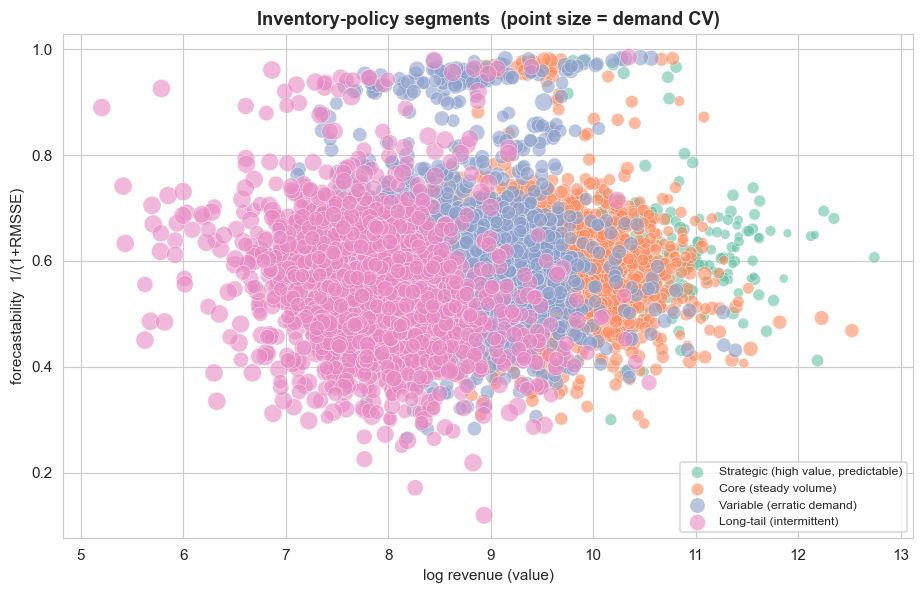

In [5]:
fig, ax = plt.subplots(figsize=(8.5,5.5))
palette = dict(zip(labels, sns.color_palette("Set2", len(labels))))
for seg in labels:
    s = df[df["segment"]==seg]
    ax.scatter(s["log_rev"], s["forecastability"], s=20+120*s["cv"]/df["cv"].max(),
               alpha=0.6, label=seg, color=palette[seg], edgecolor="white", linewidth=0.4)
ax.set_xlabel("log revenue (value)"); ax.set_ylabel("forecastability  1/(1+RMSSE)")
ax.set_title("Inventory-policy segments  (point size = demand CV)", fontweight="bold")
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

Save the segment assignment and service-level target for each series.

In [6]:
out = df[["series_id","item_id","store_id","state_id","cat_id",
          "mean_units","total_rev","rmsse","cv","zero_frac",
          "segment","service_target","policy_class"]]
out.to_parquet(ROOT/"data"/"segments.parquet", index=False)
print("saved segments.parquet")
out.groupby("segment").agg(n=("series_id","size"),
    avg_service=("service_target","mean"),
    avg_rmsse=("rmsse","mean"), rev_share=("total_rev", lambda s: s.sum())).round(3)

saved segments.parquet


,n,avg_service,avg_rmsse,rev_share
segment,,,,
Core (steady volume),2934,0.95,0.738,44892328.0
Long-tail (intermittent),2115,0.88,0.896,6831700.0
"Strategic (high value, predictable)",218,0.98,0.656,11518185.0
Variable (erratic demand),4733,0.92,0.725,28732632.0
